![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la [competencia de Kaggle](https://www.kaggle.com/competitions/miad-2025-12-prediccion-popularidad-en-cancion).

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

In [1]:
#Librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#importar dataset.csv
df_train = pd.read_csv('dataTrain_Spotify.csv')
df_test = pd.read_csv('dataTest_Spotify.csv')

In [3]:
#Se guarda la variable 'popularity' como la variable a predecir en el modelo
y_train=df_train['popularity']
#Se guarda el dataset de entrenamiento quitando la variable a predecir y las columnas que no se consideran importantes para el modelo
x_train=df_train.drop(columns=['Unnamed: 0','track_id','artists','album_name','track_name','popularity'])
#Se guarda el dataset de prueba quitando las columnas que no se consideran importantes para el modelo
x_test=df_test.drop(columns=['Unnamed: 0','track_id','artists','album_name','track_name'])

In [4]:
x_train.head()

,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,211533,False,0.305,0.8490,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth
1,196000,False,0.287,0.1900,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera
2,216506,False,0.583,0.5090,1,-9.661,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm
3,218346,False,0.163,0.0368,8,-23.149,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical
4,173160,False,0.647,0.9210,2,-7.294,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno


## 1. Pre procesamiento de datos

In [5]:
#Se verifica que no haya valores nulos en los datos
y_train.isna().sum().sum() == x_train.isna().sum().sum() == x_test.isna().sum().sum() == 0

np.True_

In [6]:
#Se codifican en 1 (True) y 0 (False) los valores de la columna 'Explicit'
x_train['explicit'] = x_train['explicit'].astype(int)
x_test['explicit'] = x_test['explicit'].astype(int)

In [7]:
x_train.head()

,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,211533,0,0.305,0.8490,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth
1,196000,0,0.287,0.1900,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera
2,216506,0,0.583,0.5090,1,-9.661,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm
3,218346,0,0.163,0.0368,8,-23.149,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical
4,173160,0,0.647,0.9210,2,-7.294,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno


In [8]:
#Se verifica la cantidad de generos únicos
generos_train=x_train['track_genre'].unique()
generos_test=x_test['track_genre'].unique()

In [9]:
#Se verifica que los generos únicos en train sean los mismos que en test
set(generos_train) == set(generos_test)

True

In [10]:
# Se decide eliminar la columna de genero por la gran cantidad de valores únicos y que al realizar un one hot encoding agregarían 114 variables al modelo
len(generos_train)

114

In [11]:
x_train=x_train.drop(columns=['track_genre'])
x_test=x_test.drop(columns=['track_genre'])

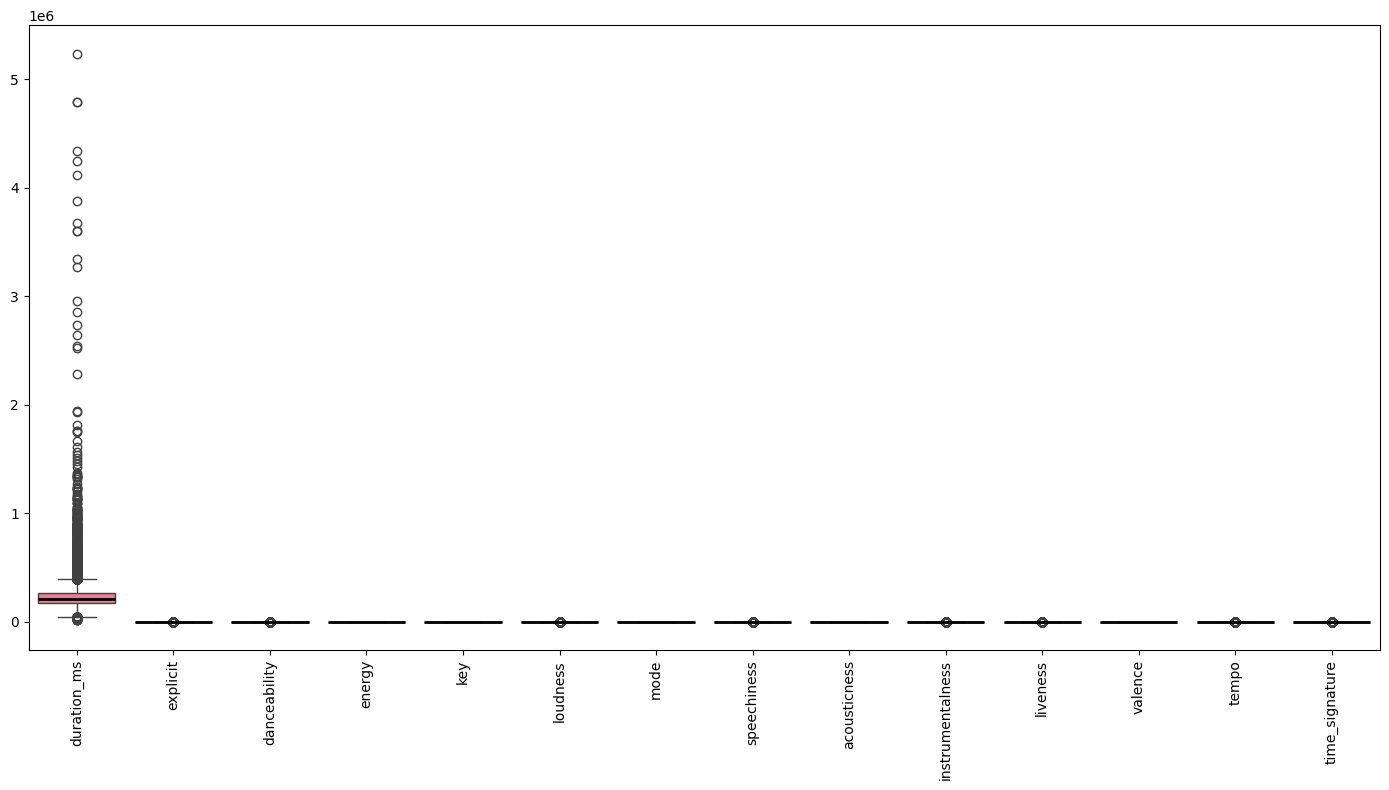

In [12]:
#Se observa una distribución irregular en la variable 'duration_ms'
plt.figure(figsize=(14, 8))
g=sns.boxplot(data=x_train, patch_artist=True, medianprops=dict(color='black', linewidth=2))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [14]:
#El percentil P75 de las canciones está por debajo de 4.35 minutos, la canción más larga es de 87 minutos
(x_train['duration_ms']/60000).describe()

count    79800.000000
mean         3.798370
std          1.750998
min          0.223100
25%          2.907267
50%          3.546883
75%          4.357100
max         87.288250
Name: duration_ms, dtype: float64

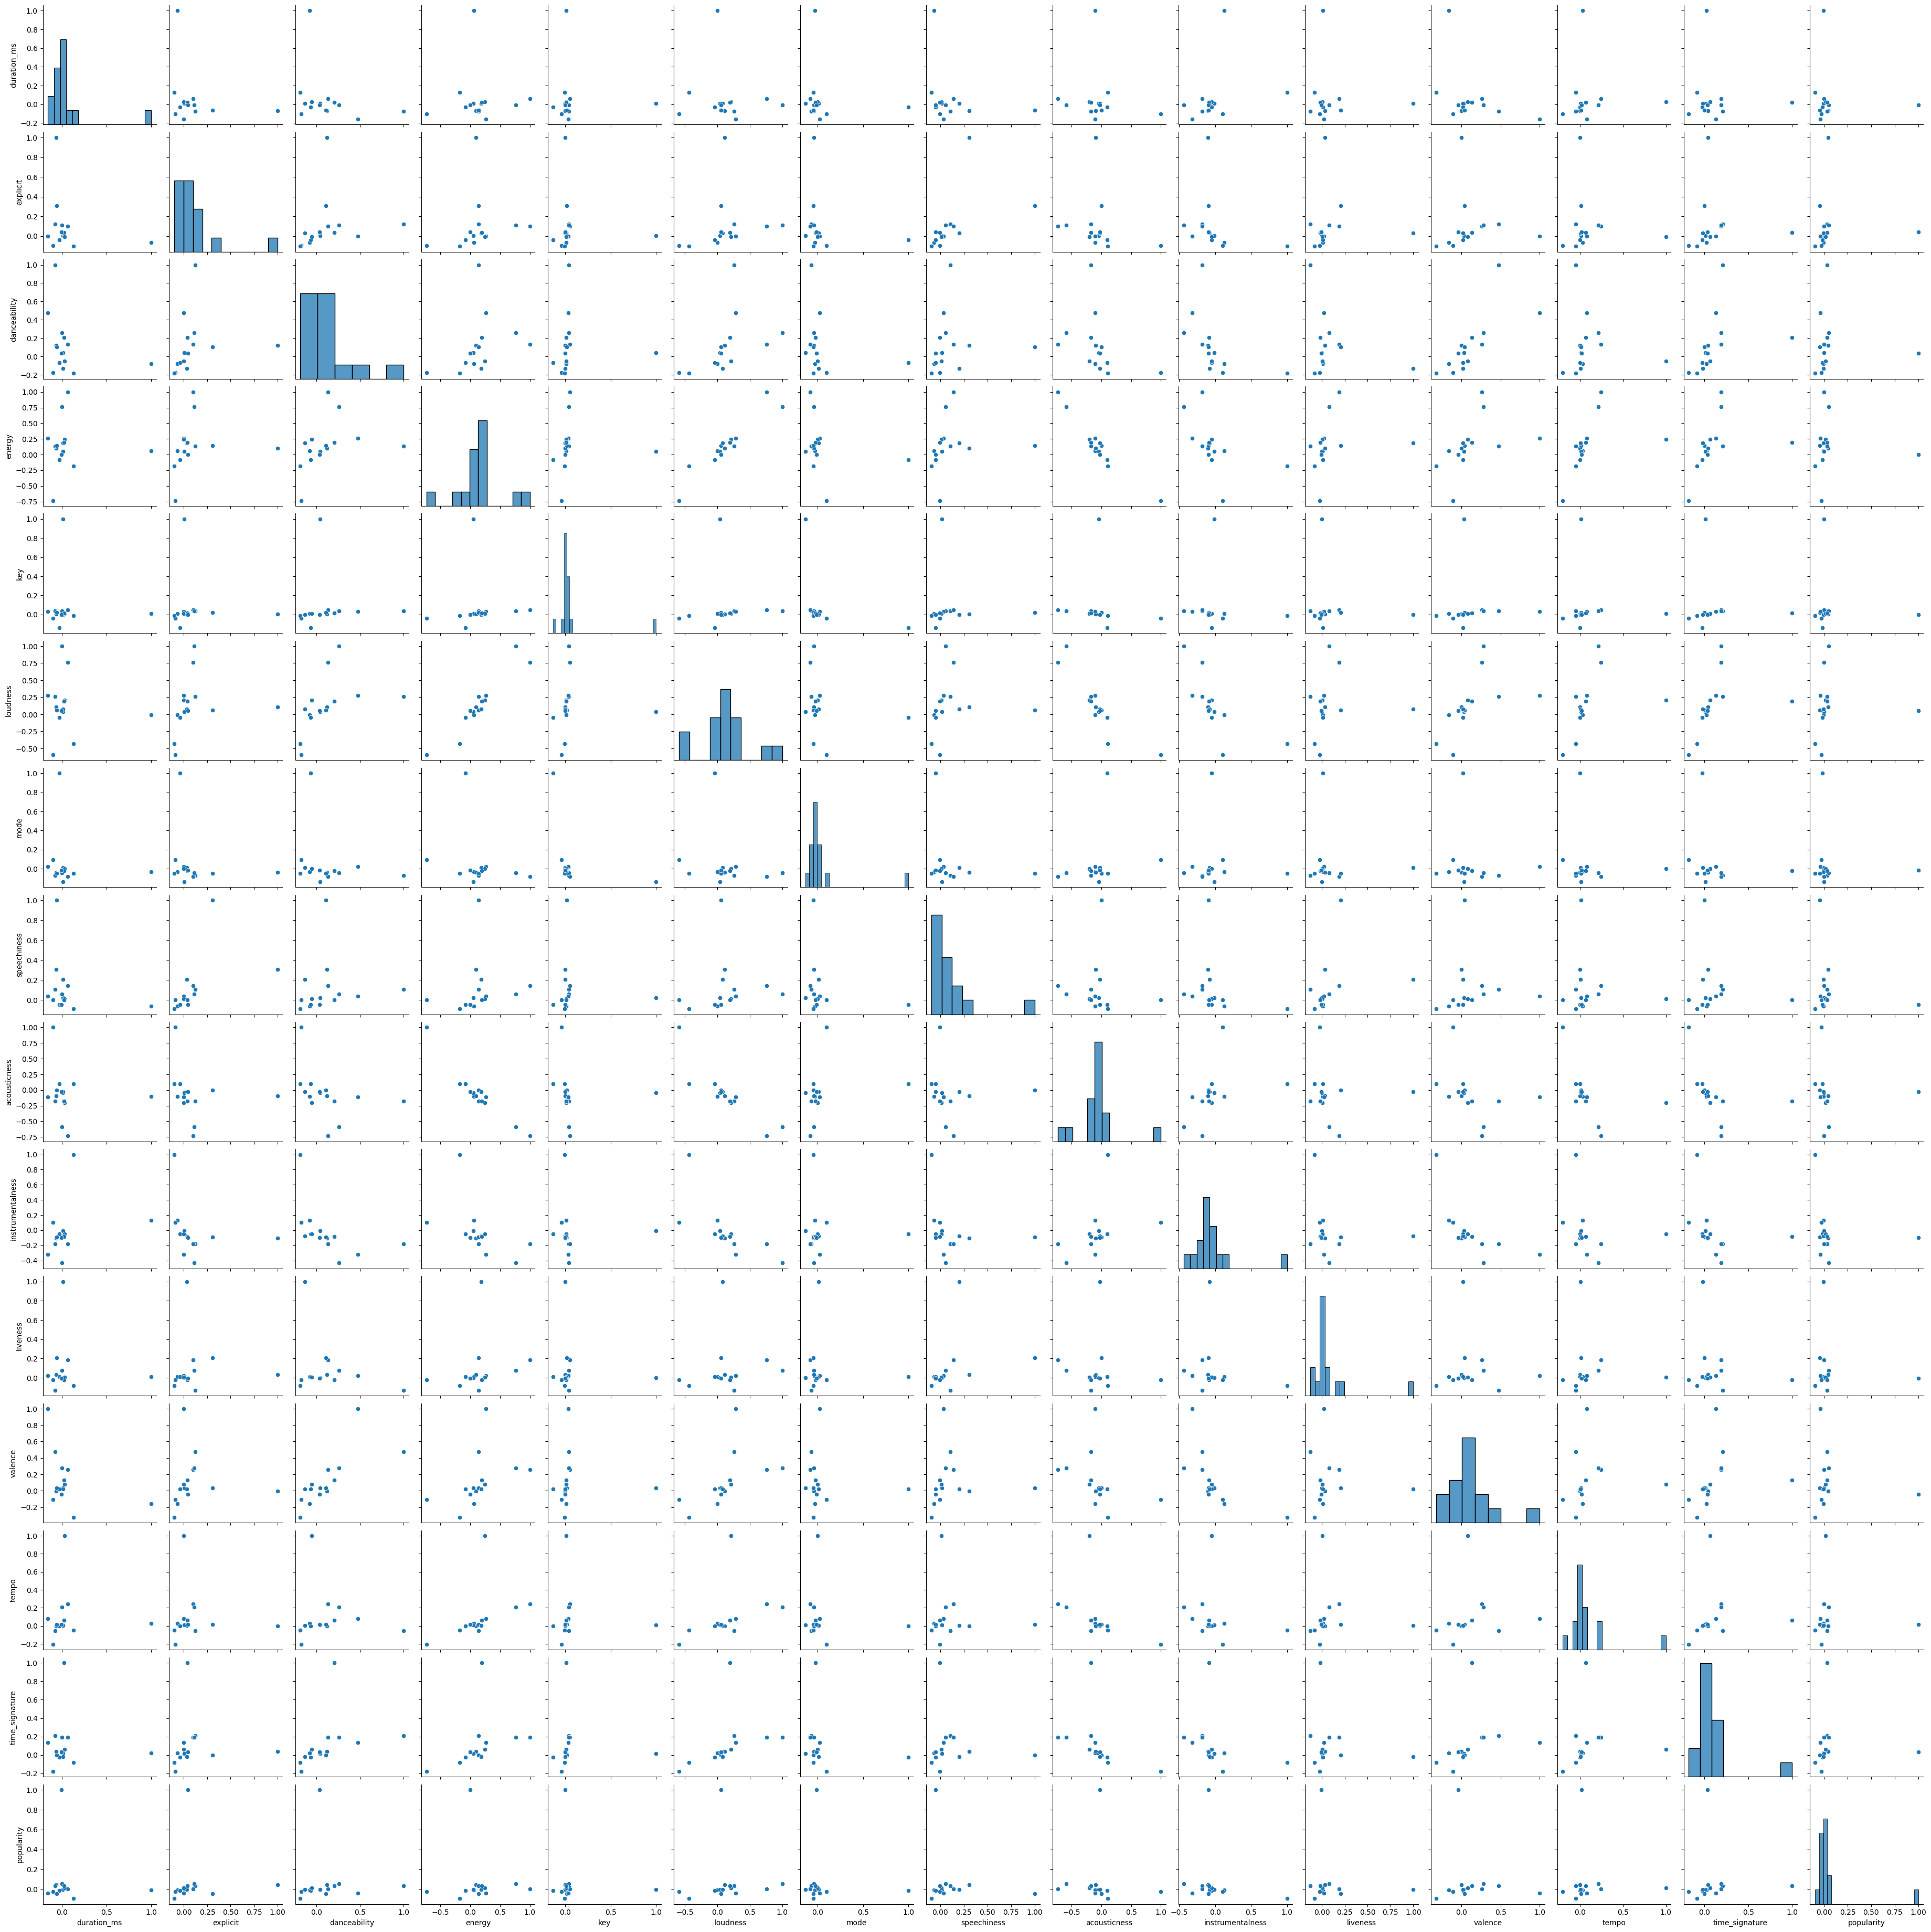

In [15]:
#Pairplot
sns.pairplot(pd.concat([x_train, y_train], axis=1).corr(), kind="scatter")

## 2. Calibración del modelo

### 2.1 Random Forest

In [16]:
#Librerias RF
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

In [17]:
# Calibración de n_estimators
# # Creación de lista de valores para iterar sobre diferentes valores de n_estimators
estimator_range = range(30, 310, 30)

# Definición de lista para almacenar la exactitud (RMSE) promedio para cada valor de n_estimators
rmse_scores = []

# Uso de un 5-fold cross-validation para cada valor de n_estimators
for estimator in estimator_range:
    reg = RandomForestRegressor(n_estimators=estimator, random_state=1, n_jobs=-1)
    scores = cross_val_score(reg, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    rmse_scores.append(rmse)
    print(f"n_estimators: {estimator}, RMSE: {rmse:.2f}")

# Encontrar el valor óptimo de n_estimators
optimal_estimator = estimator_range[rmse_scores.index(min(rmse_scores))]
print(f"\nMejor n_estimators: {optimal_estimator} con RMSE: {min(rmse_scores):.2f}")

n_estimators: 30, RMSE: 16.35
n_estimators: 60, RMSE: 16.20
n_estimators: 90, RMSE: 16.14
n_estimators: 120, RMSE: 16.10
n_estimators: 150, RMSE: 16.08
n_estimators: 180, RMSE: 16.06
n_estimators: 210, RMSE: 16.06
n_estimators: 240, RMSE: 16.05
n_estimators: 270, RMSE: 16.05
n_estimators: 300, RMSE: 16.04

Mejor n_estimators: 300 con RMSE: 16.04


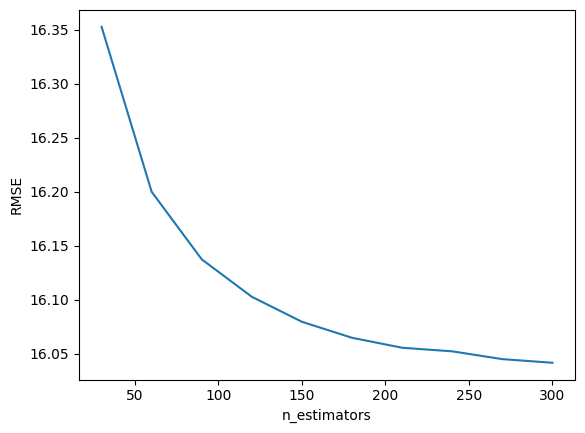

In [18]:
# Gráfica del desempeño del modelo vs la cantidad de n_estimators
plt.plot(estimator_range, rmse_scores)
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.show()

In [19]:
# Calibración de max_features con el numero optimo de estimadores calibrado (300)

# Creación de lista de valores para iterar sobre diferentes valores de max_features
feature_range = range(1, x_train.shape[1] + 1)

# Definición de lista para almacenar la exactitud (RMSE) promedio para cada valor de max_features
rmse_scores = []

# Uso de un 10-fold cross-validation para cada valor de max_features
for feature in feature_range:
    reg = RandomForestRegressor(n_estimators=optimal_estimator, max_features=feature, random_state=1, n_jobs=-1)
    scores = cross_val_score(reg, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    rmse_scores.append(rmse)
    print(f"max_features: {feature}, RMSE: {rmse:.2f}")

# Encontrar el valor óptimo de max_features
optimal_feature = feature_range[rmse_scores.index(min(rmse_scores))]
print(f"\nMejor max_features: {optimal_feature} con RMSE: {min(rmse_scores):.3f}")

max_features: 1, RMSE: 16.08
max_features: 2, RMSE: 16.00
max_features: 3, RMSE: 15.98
max_features: 4, RMSE: 15.98
max_features: 5, RMSE: 15.98
max_features: 6, RMSE: 15.98


KeyboardInterrupt: 

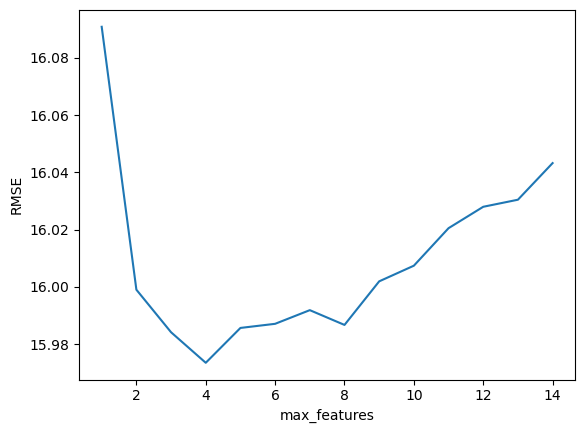

In [60]:
# Gráfica del desempeño del modelo vs la cantidad de max_features
plt.plot(feature_range, rmse_scores)
plt.xlabel('max_features')
plt.ylabel('RMSE')
plt.show()

In [68]:
# Calibración de max_depth con el numero máximo de variables predictoras (4) y estimadores calibrados anteriormente (300)

# Valores a probar para max_depth
depth_range = range(2, 50)

# Lista para guardar los RMSE promedio
rmse_scores = []

# Validación cruzada para cada valor de max_depth
for depth in depth_range:
    reg = RandomForestRegressor(n_estimators=optimal_estimator, max_features=optimal_feature, max_depth=depth, random_state=1, n_jobs=-1)
    scores = cross_val_score(reg, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    rmse_scores.append(rmse)
    print(f"max_depth: {depth}, RMSE: {rmse:.3f}")

# Encontrar el valor óptimo de max_depth
optimal_depth = depth_range[rmse_scores.index(min(rmse_scores))]
print(f"\nMejor max_depth: {optimal_depth} con RMSE: {min(rmse_scores):.3f}")

max_depth: 2, RMSE: 22.083
max_depth: 3, RMSE: 21.946
max_depth: 4, RMSE: 21.812
max_depth: 5, RMSE: 21.673
max_depth: 6, RMSE: 21.523
max_depth: 7, RMSE: 21.353
max_depth: 8, RMSE: 21.159
max_depth: 9, RMSE: 20.931
max_depth: 10, RMSE: 20.656
max_depth: 11, RMSE: 20.351
max_depth: 12, RMSE: 20.021
max_depth: 13, RMSE: 19.652
max_depth: 14, RMSE: 19.271
max_depth: 15, RMSE: 18.881
max_depth: 16, RMSE: 18.508
max_depth: 17, RMSE: 18.151
max_depth: 18, RMSE: 17.803
max_depth: 19, RMSE: 17.498
max_depth: 20, RMSE: 17.234
max_depth: 21, RMSE: 16.972
max_depth: 22, RMSE: 16.783
max_depth: 23, RMSE: 16.599
max_depth: 24, RMSE: 16.459
max_depth: 25, RMSE: 16.355
max_depth: 26, RMSE: 16.261
max_depth: 27, RMSE: 16.191
max_depth: 28, RMSE: 16.144
max_depth: 29, RMSE: 16.104
max_depth: 30, RMSE: 16.065
max_depth: 31, RMSE: 16.042
max_depth: 32, RMSE: 16.023
max_depth: 33, RMSE: 16.008
max_depth: 34, RMSE: 16.008
max_depth: 35, RMSE: 15.999
max_depth: 36, RMSE: 15.989
max_depth: 37, RMSE: 15.980


### 2.2 XG Boost

## 3. Entrenamiento del modelo

### 3.1 Random Forest

In [71]:
# Definición del modelo con los parámetros calibrados
reg = RandomForestRegressor(n_estimators=optimal_estimator, max_features=optimal_feature, max_depth=optimal_depth, random_state=1, n_jobs=-1)
reg.fit(x_train, y_train)

# Validación cruzada con 10 folds (cv=10) usando MSE
scores = cross_val_score(reg, x_train, y_train, cv=10, scoring='neg_mean_squared_error')
print(f"\nRMSE del modelo de Random Forest calibrado: {min(np.sqrt(-scores)):.3f}")

# Predicciones en el conjunto de prueba
y_pred_rf = reg.predict(x_test)
y_pred_rf.shape


RMSE del modelo de Random Forest calibrado: 15.434


(34200,)

In [102]:
# Guardar predicciones en formato de la competencia de kaggle
id_col = np.arange(0, len(y_pred_rf))

df_test = pd.DataFrame({
    "ID": id_col,  # First column
    "Popularity": y_pred_rf   # Second column
})

df_test.to_csv('y_pred_RF_calibrado.csv', index_label='ID',index=False)
df_test.head()

,ID,Popularity
0,0,45.123056
1,1,16.364167
2,2,28.060232
3,3,0.041456
4,4,35.629591


### 3.2 XG Boost

## 4. Disponibilización del modelo

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Definición del modelo con los parámetros calibrados
reg = RandomForestRegressor(n_estimators=10, random_state=42)
reg.fit(x_train, y_train)

# Validación cruzada con 10 folds (cv=10) usando MSE
scores = cross_val_score(reg, x_train, y_train, cv=10, scoring='neg_mean_squared_error')
print(f"\nRMSE del modelo de Random Forest calibrado: {min(np.sqrt(-scores)):.3f}")

# Predicciones en el conjunto de prueba
y_pred_rf = reg.predict(x_test)
y_pred_rf.shape


RMSE del modelo de Random Forest calibrado: 16.406


(34200,)

In [34]:
# Exportar modelo a archivo binario .pkl
import joblib
joblib.dump(reg, 'reg_popularidad.pkl', compress=3)

['reg_popularidad.pkl']

In [35]:
# Importación librerías
from flask import Flask
from flask_restx import Api, Resource, fields

In [ ]:
app = Flask(__name__)
api = Api(app, version='1.0', title='Popularity Prediction API',
          description='Predice la popularidad de canciones a partir de sus características')

ns = api.namespace('Predict', description='Modelo de regresión')

# Cargar el modelo
modelo = joblib.load("reg_popularidad.pkl")

# Definir modelo de entrada JSON
input_model = api.model('SongFeatures', {
    'duration_ms': fields.Float(required=True),
    'explicit': fields.Integer(required=True),
    'danceability': fields.Float(required=True),
    'energy': fields.Float(required=True),
    'key': fields.Integer(required=True),
    'loudness': fields.Float(required=True),
    'mode': fields.Integer(required=True),
    'speechiness': fields.Float(required=True),
    'acousticness': fields.Float(required=True),
    'instrumentalness': fields.Float(required=True),
    'liveness': fields.Float(required=True),
    'valence': fields.Float(required=True),
    'tempo': fields.Float(required=True),
    'time_signature': fields.Integer(required=True)
})

# Respuesta esperada
output_model = api.model('Prediction', {
    'result': fields.String
})

In [37]:
# Definición de la clase para disponibilización
@ns.route('/')
class PopularityRegressor(Resource):
    @ns.expect(input_model)
    @ns.marshal_with(output_model)
    def post(self):
        data = api.payload

        features = np.array([[
            data['duration_ms'],
            data['explicit'],
            data['danceability'],
            data['energy'],
            data['key'],
            data['loudness'],
            data['mode'],
            data['speechiness'],
            data['acousticness'],
            data['instrumentalness'],
            data['liveness'],
            data['valence'],
            data['tempo'],
            data['time_signature']
        ]])

        pred = modelo.predict(features)[0]
        return {'result': f'{pred:.2f}'}

In [38]:
# Ejecutar la app
if __name__ == '__main__':
    app.run(debug=True, use_reloader=False, host='0.0.0.0', port=5000)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.0.28:5000
Press CTRL+C to quit
127.0.0.1 - - [24/Apr/2025 21:01:55] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2025 21:01:55] "GET /swaggerui/droid-sans.css HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2025 21:01:55] "GET /swaggerui/swagger-ui.css HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2025 21:01:55] "GET /swaggerui/swagger-ui-bundle.js HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2025 21:01:55] "GET /swaggerui/swagger-ui-standalone-preset.js HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2025 21:01:55] "GET /swagger.json HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2025 21:01:55] "GET /swaggerui/favicon-32x32.png HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2025 21:04:39] "GET /predict/ HTTP/1.1" 405 -
127.0.0.1 - - [24/Apr/2025 21:05:13] "GET /predict/ HTTP/1.1" 405 -
127.0.0.1 - - [24/Apr/2025 21:06:34] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2025 21:06:34] "GET /swaggerui/droid-sans.css HTTP/1.1" 304 -
127.0.0.

##OPCION 1##

In [ ]:
app = Flask(__name__)

# Definición API Flask
api = Api(
    app, 
    version='1.0', 
    title='Popularity Prediction API',
    description='API para predecir la popularidad de canciones')

ns = api.namespace('predict', description='Modelo de regresión')

# Cargar el modelo
modelo = joblib.load("reg_popularidad.pkl")

# Definición de los argumentos (por URL)
parser = ns.parser()
parser.add_argument('duration_ms', type=float, required=True)
parser.add_argument('explicit', type=int, required=True)
parser.add_argument('danceability', type=float, required=True)
parser.add_argument('energy', type=float, required=True)
parser.add_argument('key', type=int, required=True)
parser.add_argument('loudness', type=float, required=True)
parser.add_argument('mode', type=int, required=True)
parser.add_argument('speechiness', type=float, required=True)
parser.add_argument('acousticness', type=float, required=True)
parser.add_argument('instrumentalness', type=float, required=True)
parser.add_argument('liveness', type=float, required=True)
parser.add_argument('valence', type=float, required=True)
parser.add_argument('tempo', type=float, required=True)
parser.add_argument('time_signature', type=int, required=True)

# Respuesta esperada
resource_fields = api.model('Resource', {
    'result': fields.String,
})

In [ ]:
# Definición de la clase para disponibilización
@ns.route('/')
class PopularityRegressor(Resource):
    @ns.doc(parser=parser)
    @ns.marshal_with(resource_fields)
    def get(self):
        args = parser.parse_args()

        features = np.array([[
            args['duration_ms'],
            args['explicit'],
            args['danceability'],
            args['energy'],
            args['key'],
            args['loudness'],
            args['mode'],
            args['speechiness'],
            args['acousticness'],
            args['instrumentalness'],
            args['liveness'],
            args['valence'],
            args['tempo'],
            args['time_signature']
        ]])

        pred = modelo.predict(features)[0]
        return {'result': f'{pred:.2f}'}

In [ ]:
if __name__ == '__main__':
    app.run(debug=True, use_reloader=False, host='0.0.0.0', port=5000)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.0.28:5000
Press CTRL+C to quit
127.0.0.1 - - [24/Apr/2025 20:40:48] "GET /predict?duration_ms=210000&explicit=0&danceability=0.8&energy=0.7&key=5&loudness=-5.0&mode=1&speechiness=0.04&acousticness=0.3&instrumentalness=0.0&liveness=0.2&valence=0.9&tempo=120.0&time_signature=4 HTTP/1.1" 308 -
c:\Users\Lizt1\anaconda3\envs\mi_entorno\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
127.0.0.1 - - [24/Apr/2025 20:40:48] "GET /predict/?duration_ms=210000&explicit=0&danceability=0.8&energy=0.7&key=5&loudness=-5.0&mode=1&speechiness=0.04&acousticness=0.3&instrumentalness=0.0&liveness=0.2&valence=0.9&tempo=120.0&time_signature=4 HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2025 20:40:48] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [24/Apr/2025 20:49:16] "GET /predict/ HTTP

## 5. Conclusiones

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importación librerías
import pandas as pd
import numpy as np

In [ ]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/dataTest_Spotify.csv', index_col=0)

In [ ]:
# Visualización datos de entrenamiento
dataTraining.head()

In [ ]:
# Visualización datos de test
dataTesting.head()

In [ ]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
np.random.seed(42)
y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

In [ ]:
# Guardar predicciones en formato exigido en la competencia de kaggle
y_pred.to_csv('test_submission_file.csv', index_label='ID')
y_pred.head()